In [102]:
import pandas as pd
import numpy as np
import matplotlib
import ast
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

#폰트 설정(없으면 영문으로 나옴)
try:
    font_path = [f for f in fm.findSystemFonts() if 'NanumGothic' in f or 'Malgun' in f or 'AppleGothic' in f]
    if font_path:
        plt.rcParams['font.family'] = fm.FontProperties(fname=font_path[0]).get_name()
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'
except:
    plt.rcParams['font.family'] = 'DejaVu Sans'

plt.rcParams['axes.unicode_minus'] = False

In [103]:
full = pd.read_csv('../dataset/final_eda.csv')

In [104]:
received = (
    full.loc[full['event'] == 'offer received', ['customer_id', 'offer_id', 'time', 'offer_type']]
    .rename(columns={'time': 't_received'})
    .sort_values(['customer_id', 'offer_id', 't_received'])
    .reset_index(drop=True)
)
viewed = (
    full.loc[full['event'] == 'offer viewed', ['customer_id', 'offer_id', 'time', 'offer_type']]
    .rename(columns={'time': 't_viewed'})
    .sort_values(['customer_id', 'offer_id', 't_viewed'])
    .reset_index(drop=True)
)
completed = (
    full.loc[full['event'] == 'offer completed', ['customer_id', 'offer_id', 'time', 'offer_type']]
    .rename(columns={'time': 't_completed'})
    .sort_values(['customer_id', 'offer_id', 't_completed'])
    .reset_index(drop=True)
)

# 같은 고객, 같은 오퍼를 수신 받았을 때 instance_id 각각 부여 (모두 1로, 똑같은 객체가 들어오면 그때 2)
# t_received에 따라서 순서대로 instance_id가 1,2,3,... 으로 배정
received['instance_id'] = received.groupby(['customer_id', 'offer_id']).cumcount() + 1

portfolio_dur = (
    full[['offer_id', 'duration']]
    .dropna(subset=['offer_id'])
    .drop_duplicates('offer_id')
)
received = received.merge(portfolio_dur, on='offer_id', how='left')

# [경계조건] t_expire = t_received + duration * 24
# - transcript.time 단위: 시간(hour), portfolio.duration 단위: 일(day) → *24 변환
# - 경계: t_received <= event_time <= t_expire (양 끝 포함, closed interval)
#   → 수신 시각과 만료 시각 정확히 일치하는 이벤트도 유효로 처리
#   → strict (<) 버전은 사용하지 않음 (수신 즉시 이벤트 발생 사례 존재)
received['t_expire'] = received['t_received'] + received['duration'] * 24

recv_keys = received[['customer_id', 'offer_id', 't_received', 'instance_id', 't_expire']]

In [105]:
def interval_join(events_df, event_time_col):
    # [경계조건] t_received <= t_event <= t_expire (양 끝 포함)
    # [ambiguous match 처리 규칙]
    #   - 같은 이벤트가 복수의 수신 구간에 걸칠 경우(ambiguous_match=1),
    #     t_received가 가장 최근인(=직전에 수신된) instance를 선택
    #   - 근거: 가장 최근 수신 오퍼에 반응했을 가능성이 가장 높다고 가정
    events_df = events_df.copy()
    events_df['_row_id'] = range(len(events_df))
    merged = events_df.merge(recv_keys, on=['customer_id', 'offer_id'], how='left') # 겹치는게 엄청 많을 거임 on 조건이 인스턴스 조건 뿐이므로!
    valid = merged[ # 하지만 여기서 필터링을 걸어줘서 구간 내에 포함되는 view와 receive 행만 추출
        (merged['t_received'] <= merged[event_time_col]) &
        (merged[event_time_col] <= merged['t_expire'])
    ].copy()
    match_cnt = ( # 같은 view 행에서 몇개의 receive 행이 연결되었는지 카운트
        valid.groupby('_row_id')['instance_id']
        .count().reset_index(name='match_count')
    )
    valid = valid.merge(match_cnt, on='_row_id')
    valid['ambiguous_match'] = (valid['match_count'] > 1).astype(int)
    valid = (
        valid.sort_values('t_received', ascending=False) # 같은 구간내에 여러개의 수신 인스턴스가 존재한다면 최근 수신된 인스턴스 선택
        .drop_duplicates(subset='_row_id', keep='first')
        .drop(columns='_row_id')
    )
    return valid

view_map = interval_join(viewed, 't_viewed')
comp_map = interval_join(completed, 't_completed')


In [106]:
view_map = view_map.sort_values(by=['customer_id','offer_id'])
view_map

,customer_id,offer_id,t_viewed,offer_type,t_received,instance_id,t_expire,match_count,ambiguous_match
0,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,372,informational,336,1,432.0,1,0
1,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,192,informational,168,1,240.0,1,0
2,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,456,bogo,408,1,528.0,1,0
3,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,540,discount,504,1,744.0,1,0
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,630,bogo,576,2,696.0,1,0
...,...,...,...,...,...,...,...,...,...
58929,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,582,discount,576,3,744.0,1,0
58928,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,414,discount,408,2,576.0,2,1
58926,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,354,discount,336,1,504.0,1,0
58930,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,534,bogo,504,1,672.0,1,0


In [107]:
comp_map = comp_map.sort_values(by=['customer_id','offer_id'])
comp_map

,customer_id,offer_id,t_completed,offer_type,t_received,instance_id,t_expire,match_count,ambiguous_match
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,576,1,744.0,1,0
1,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,414,bogo,408,1,528.0,1,0
2,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,528,discount,504,1,744.0,1,0
3,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,576,discount,408,1,648.0,1,0
4,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,252,discount,168,1,336.0,1,0
...,...,...,...,...,...,...,...,...,...
35373,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,576,discount,576,3,744.0,2,1
35371,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,414,discount,408,2,576.0,2,1
35369,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,384,discount,336,1,504.0,1,0
35374,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,bogo,504,1,672.0,1,0


In [108]:
# == [품질 체크 1] 이벤트 중복 매핑 확인 ==
dup_view_map = view_map[view_map.duplicated()]
print(f"중복건: {len(dup_view_map)}개") # 중복 없음

dup_comp_map = comp_map[comp_map.duplicated()]
print(f"중복건: {len(dup_comp_map)}개") # 중복 존재

중복건: 0개
중복건: 397개


In [109]:
n_no_match_v = len(viewed) - len(view_map)
n_no_match_c = len(completed) - len(comp_map)
n_ambig_v = view_map['ambiguous_match'].sum()
n_ambig_c = comp_map['ambiguous_match'].sum()
print(f"열람: 유효 구간 밖 {n_no_match_v:,}건 / ambiguous {n_ambig_v:,}건") # 한 view 행이 여러 receive 행과 연결될 수 있는 모호한 건 수
print(f"완료: 유효 구간 밖 {n_no_match_c:,}건 / ambiguous {n_ambig_c:,}건") # 한 complete 행이 여러 receive 행과 연결될 수 있는 모호한 건 수

view_summary = (
    view_map.groupby(['customer_id', 'offer_id', 'instance_id'], as_index=False)
    .agg(
        first_viewed=('t_viewed', 'min'),
        last_viewed=('t_viewed', 'max'),
        view_count=('t_viewed', 'count'),
        view_ambiguous=('ambiguous_match', 'max')
    )
)

comp_summary = (
    comp_map.groupby(['customer_id', 'offer_id', 'instance_id'], as_index=False)
    .agg(
        first_completed=('t_completed', 'min'),
        last_completed=('t_completed', 'max'),
        complete_count=('t_completed', 'count'), # 같은 t_receive(instance_id), customer_id, offer_id를 몇번 완료했는지 카운트
        comp_ambiguous=('ambiguous_match', 'max')
    )
)

열람: 유효 구간 밖 1,158건 / ambiguous 2,339건
완료: 유효 구간 밖 0건 / ambiguous 1,776건


In [110]:
view_summary[view_summary['view_count']>1]

,customer_id,offer_id,instance_id,first_viewed,last_viewed,view_count,view_ambiguous


In [111]:
comp_summary[(comp_summary['complete_count']>1)&(comp_summary['first_completed']!=comp_summary['last_completed'])]

,customer_id,offer_id,instance_id,first_completed,last_completed,complete_count,comp_ambiguous
294,0246e7cc7a3d4a98a940cb13776b5b55,fafdcd668e3743c1bb461111dcafc2a4,2,582,624,2,1
505,041fd7c6b796430a867c4e03d2ff8f4d,0b1e1539f2cc45b7b9fa7c272da2e1d7,3,648,702,2,1
745,05e6bcb70fe14e0da4730527ca35a4ae,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,510,540,2,1
754,05f4d69f73024172a23a350e611166b4,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,414,432,2,1
904,072290a7410e49d3a1e45a89c92c58f3,2298d6c36e964ae4a3e7e9706d1fb8c2,2,432,468,2,1
...,...,...,...,...,...,...,...
30753,edc7b04392144da9979f3077095f268a,fafdcd668e3743c1bb461111dcafc2a4,3,474,498,2,1
31489,f3934f05d51f47c7a470661cbb774075,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,456,462,2,1
31996,f74033a8c6834303bd1b3ef0c98d11d8,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,576,714,2,1
31999,f7465d18ba7f4e43b99ccabf141d421d,2906b810c7d4411798c6938adc9daaa5,3,504,594,2,1


In [112]:
# == [품질 체크 2] 이벤트 중복 매핑 & tie-break 확인 ==

# 1. 한 이벤트가 여러 instance에 중복 매핑되지 않는지
dup_view = view_summary.duplicated().sum()
dup_comp = comp_summary.duplicated().sum()
print(f"[중복 매핑] view_summary: {dup_view}건 / comp_summary: {dup_comp}건 (0이어야 정상)")
assert dup_view == 0, f'view_map 중복 매핑 {dup_view}건 존재'
assert dup_comp == 0, f'comp_summary 중복 매핑 {dup_comp}건 존재'

print("\n✓ 중복 매핑 체크 통과 \n")

# 2. ambiguous match 건수 확인 (tie-break: 최근 t_received 기준 1개 선택)
ambig_v = view_summary['view_ambiguous'].sum()
ambig_c = comp_summary['comp_ambiguous'].sum()
print(f"[Ambiguous match] view: {ambig_v:,}건 / comp: {ambig_c:,}건 → 최근 수신 instance 선택")

"""
[중복 매핑] view_summary: 0건 / comp_summary: 0건 (0이어야 정상)
[Ambiguous match] view: 2,339건 / comp: 1,328건 → 최근 수신 instance 선택

✓ 중복 매핑 체크 통과
"""

[중복 매핑] view_summary: 0건 / comp_summary: 0건 (0이어야 정상)

✓ 중복 매핑 체크 통과 

[Ambiguous match] view: 2,339건 / comp: 1,328건 → 최근 수신 instance 선택


'\n[중복 매핑] view_summary: 0건 / comp_summary: 0건 (0이어야 정상)\n[Ambiguous match] view: 2,339건 / comp: 1,328건 → 최근 수신 instance 선택\n\n✓ 중복 매핑 체크 통과\n'

In [113]:
funnel_instance = (
    received.merge(view_summary, on=['customer_id', 'offer_id', 'instance_id'], how='left')
            .merge(comp_summary, on=['customer_id', 'offer_id', 'instance_id'], how='left')
)

funnel_instance['gap_to_first_view'] = funnel_instance['first_viewed'] - funnel_instance['t_received']
funnel_instance['gap_to_first_complete'] = funnel_instance['first_completed'] - funnel_instance['t_received']
funnel_instance['is_viewed'] = funnel_instance['first_viewed'].notna()
funnel_instance['is_completed'] = funnel_instance['first_completed'].notna()
funnel_instance['completed_without_prior_view'] = (
    (funnel_instance['is_completed'] & ~funnel_instance['is_viewed'])
    | (funnel_instance['first_completed'] < funnel_instance['first_viewed'])  # 완료가 열람보다 먼저인 경우
)

# prior view가 있고 시간 순서가 맞는 경우에만 gap 계산 (시간 순서 확실한 것만)
mask = (
    funnel_instance['first_viewed'].notna() &
    funnel_instance['first_completed'].notna() &
    (funnel_instance['first_viewed'] < funnel_instance['first_completed'])
)
funnel_instance['gap_first_view_to_first_complete'] = np.where(
    mask,
    funnel_instance['first_completed'] - funnel_instance['first_viewed'],
    np.nan
)

In [114]:
first_viewed_instance = ( # 같은 오퍼를 여러번 받은 경우 이벤트를 '열람'한 오퍼
    funnel_instance[funnel_instance['is_viewed']]
    .groupby(['customer_id','offer_id'])['instance_id']
    .min()
    .reset_index(name = 'first_viewed_instance')
)

first_viewed_instance['first_viewed_instance'].value_counts() # 경향만 보는 것으로!

first_viewed_instance
1    47024
2     1146
3       42
4        1
Name: count, dtype: int64

In [115]:
funnel_instance.sort_values(by=['customer_id','offer_id','instance_id'])

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,first_viewed,last_viewed,view_count,view_ambiguous,first_completed,last_completed,complete_count,comp_ambiguous,gap_to_first_view,gap_to_first_complete,is_viewed,is_completed,completed_without_prior_view,gap_first_view_to_first_complete
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,False,True,True,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,True,False,False,NaN
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,True,False,False,NaN
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,True,True,True,NaN
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,True,True,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76272,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,336,discount,1,7.0,504.0,354.0,354.0,1.0,0.0,384.0,384.0,1.0,0.0,18.0,48.0,True,True,False,30.0
76273,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,408,discount,2,7.0,576.0,414.0,414.0,1.0,1.0,414.0,414.0,1.0,1.0,6.0,6.0,True,True,False,NaN
76274,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,576,discount,3,7.0,744.0,582.0,582.0,1.0,0.0,576.0,576.0,1.0,1.0,6.0,0.0,True,True,True,NaN
76275,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,bogo,1,7.0,672.0,534.0,534.0,1.0,0.0,504.0,504.0,1.0,0.0,30.0,0.0,True,True,True,NaN


In [116]:
funnel_instance.info()

<class 'pandas.DataFrame'>
RangeIndex: 76277 entries, 0 to 76276
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   customer_id                       76277 non-null  str    
 1   offer_id                          76277 non-null  str    
 2   t_received                        76277 non-null  int64  
 3   offer_type                        76277 non-null  str    
 4   instance_id                       76277 non-null  int64  
 5   duration                          76277 non-null  float64
 6   t_expire                          76277 non-null  float64
 7   first_viewed                      56567 non-null  float64
 8   last_viewed                       56567 non-null  float64
 9   view_count                        56567 non-null  float64
 10  view_ambiguous                    56567 non-null  float64
 11  first_completed                   33101 non-null  float64
 12  last_completed 

In [117]:
print(f"\n전체 오퍼 received 인스턴스 수: {len(funnel_instance):,}건")
print("\n[ 수신 → 첫 열람 시간 간격 (열람한 인스턴스만) ]")
v = funnel_instance['gap_to_first_view'].dropna()
print(f"  평균   : {v.mean():.1f}시간 ({v.mean()/24:.1f}일)")
print(f"  중앙값 : {v.median():.1f}시간 ({v.median()/24:.1f}일)")
print(f"  6시간 내 열람 : {(v <= 6).mean()*100:.1f}%")
print(f"  24시간 내 열람: {(v <= 24).mean()*100:.1f}%")
print(f"  48시간 내 열람: {(v <= 48).mean()*100:.1f}%")

print("\n[ 수신 → 첫 완료 시간 간격 (완료한 인스턴스만) ]")
c = funnel_instance['gap_to_first_complete'].dropna()
print(f"  평균   : {c.mean():.1f}시간 ({c.mean()/24:.1f}일)")
print(f"  중앙값 : {c.median():.1f}시간 ({c.median()/24:.1f}일)")
print(f"  1일 내 완료: {(c <= 24).mean()*100:.1f}%")
print(f"  3일 내 완료: {(c <= 72).mean()*100:.1f}%")
print(f"  7일 내 완료: {(c <= 168).mean()*100:.1f}%")

print("\n[ 퍼널 요약 ]")
print(f"  Viewed rate     : {funnel_instance['is_viewed'].mean()*100:.1f}%")
print(f"  Completed rate  : {funnel_instance['is_completed'].mean()*100:.1f}%")
print(f"  완료했지만 미열람: {funnel_instance['completed_without_prior_view'].mean()*100:.1f}%")


전체 오퍼 received 인스턴스 수: 76,277건

[ 수신 → 첫 열람 시간 간격 (열람한 인스턴스만) ]
  평균   : 24.4시간 (1.0일)
  중앙값 : 12.0시간 (0.5일)
  6시간 내 열람 : 38.5%
  24시간 내 열람: 67.3%
  48시간 내 열람: 85.2%

[ 수신 → 첫 완료 시간 간격 (완료한 인스턴스만) ]
  평균   : 61.2시간 (2.5일)
  중앙값 : 48.0시간 (2.0일)
  1일 내 완료: 31.2%
  3일 내 완료: 66.8%
  7일 내 완료: 96.7%

[ 퍼널 요약 ]
  Viewed rate     : 74.2%
  Completed rate  : 43.4%
  완료했지만 미열람: 12.9%


In [118]:
funnel_instance.head(10)

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,first_viewed,last_viewed,view_count,view_ambiguous,first_completed,last_completed,complete_count,comp_ambiguous,gap_to_first_view,gap_to_first_complete,is_viewed,is_completed,completed_without_prior_view,gap_first_view_to_first_complete
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,False,True,True,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,True,False,False,NaN
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,True,False,False,NaN
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,True,True,True,NaN
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,True,True,True,NaN
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,168,bogo,1,5.0,288.0,216.0,216.0,1.0,0.0,NaN,NaN,NaN,NaN,48.0,NaN,True,False,False,NaN
6,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,576,bogo,2,5.0,696.0,630.0,630.0,1.0,0.0,NaN,NaN,NaN,NaN,54.0,NaN,True,False,False,NaN
7,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,408,discount,1,10.0,648.0,432.0,432.0,1.0,0.0,576.0,576.0,1.0,0.0,24.0,168.0,True,True,False,144.0
8,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,168,discount,1,7.0,336.0,186.0,186.0,1.0,0.0,252.0,252.0,1.0,0.0,18.0,84.0,True,True,False,66.0
9,0011e0d4e6b944f998e987f904e8c1e5,3f207df678b143eea3cee63160fa8bed,0,informational,1,4.0,96.0,6.0,6.0,1.0,0.0,NaN,NaN,NaN,NaN,6.0,NaN,True,False,False,NaN


In [119]:
funnel_instance.columns

Index(['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id',
       'duration', 't_expire', 'first_viewed', 'last_viewed', 'view_count',
       'view_ambiguous', 'first_completed', 'last_completed', 'complete_count',
       'comp_ambiguous', 'gap_to_first_view', 'gap_to_first_complete',
       'is_viewed', 'is_completed', 'completed_without_prior_view',
       'gap_first_view_to_first_complete'],
      dtype='str')

In [120]:
print("received 원건수:", len(received))
print("instance funnel 원건수:", len(funnel_instance))

received 원건수: 76277
instance funnel 원건수: 76277


In [121]:
print("Viewed rate:", funnel_instance['is_viewed'].mean()) # 오퍼 노출은 잘 된다 (0.74)
print("Completed rate:", funnel_instance['is_completed'].mean()) # 전환에서 크게 떨어진다 (0.43)
print("Completed without prior view:", (funnel_instance['completed_without_prior_view']).mean()) # 사용자가 오퍼를 안 보고도 조건을 충족해서 reward를 받음

Viewed rate: 0.7415996958454055
Completed rate: 0.4339578116601335
Completed without prior view: 0.12892483972888288


In [122]:
# 중복확인
funnel_instance[['customer_id','offer_id','instance_id']].duplicated().sum()

np.int64(0)

In [123]:
funnel_instance.groupby('offer_type')[['is_viewed', 'is_completed', 'gap_to_first_view', 'gap_to_first_complete', 'gap_first_view_to_first_complete']].mean()

,is_viewed,is_completed,gap_to_first_view,gap_to_first_complete,gap_first_view_to_first_complete
offer_type,,,,,
bogo,0.827896,0.508246,23.815842,49.562609,41.922873
discount,0.699669,0.576237,25.832007,71.402386,58.716480
informational,0.652904,0.000000,22.610837,NaN,NaN


In [124]:
funnel_instance.head()

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,first_viewed,last_viewed,view_count,view_ambiguous,first_completed,last_completed,complete_count,comp_ambiguous,gap_to_first_view,gap_to_first_complete,is_viewed,is_completed,completed_without_prior_view,gap_first_view_to_first_complete
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,False,True,True,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,True,False,False,NaN
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,True,False,False,NaN
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,True,True,True,NaN
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,True,True,True,NaN


In [125]:
# 이후 셀 참조명 통일 (first_ → 단축명) + completed_funnel_instance 재생성
funnel_instance = funnel_instance.rename(columns={
    'first_viewed':                         't_viewed',
    'first_completed':                      't_completed',
    'gap_to_first_view':                    'gap_to_view',
    'gap_to_first_complete':                'gap_to_complete',
    'gap_first_view_to_first_complete':     'gap_view_to_complete'
})
completed_funnel_instance = funnel_instance[funnel_instance['is_completed']].copy()

In [126]:
funnel_instance.to_csv('../dataset/funnel_instance.csv', index=False)

### 퍼널 인스턴스 데이터프레임 생성 완료 (인스턴스별)
### -> 다음 : 오퍼와 고객 정보 포함한 데이터프레임 생성

In [127]:
full = pd.read_csv('../dataset/final_eda.csv')
funnel = pd.read_csv('../dataset/funnel_instance.csv')

데이터 병합 시 validate 파라미터 값
- 'm:1' → 왼쪽은 중복 가능, 오른쪽은 반드시 unique
- '1:1' → 양쪽 모두 unique
- '1:m' → 왼쪽 unique, 오른쪽 중복 가능

In [128]:
# offer_id가 unique여야 하므로 validate='m:1' 검사
offer = ( # distinct offer_id
    full[['offer_id', 'reward', 'difficulty',
          'ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count']]
    .dropna(subset=['offer_id'])
    .drop_duplicates('offer_id')
)
funnel = funnel.merge(offer, on='offer_id', how='left', validate='m:1')

# customer_id가 unique여야 하므로 validate='m:1' 검사
cust_attr = ( # distinct customer_id
    full[['customer_id', 'gender', 'age_group', 'income_group',
          'join_year', 'join_month', 'join_cohort']]
    .drop_duplicates('customer_id')
)

print(f"병합 전 퍼널 데이터 행 개수: {len(funnel)}")
funnel = funnel.merge(cust_attr, on='customer_id', how='left', validate='m:1')
print(f"병합 후 퍼널 데이터 행 개수: {len(funnel)}") # 데이터 증폭 미발생 확인 완료

병합 전 퍼널 데이터 행 개수: 76277
병합 후 퍼널 데이터 행 개수: 76277


In [129]:
funnel.head()

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,t_viewed,last_viewed,view_count,view_ambiguous,t_completed,last_completed,complete_count,comp_ambiguous,gap_to_view,gap_to_complete,is_viewed,is_completed,completed_without_prior_view,gap_view_to_complete,reward,difficulty,ch_web,ch_email,ch_mobile,ch_social,channel_count,gender,age_group,income_group,join_year,join_month,join_cohort
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,False,True,True,NaN,2.0,10.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,True,False,False,NaN,0.0,0.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,True,False,False,NaN,0.0,0.0,0.0,1.0,1.0,1.0,3.0,M,30대,5-7.5만,2017,4,2017-04
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,True,True,True,NaN,5.0,5.0,1.0,1.0,1.0,1.0,4.0,M,30대,5-7.5만,2017,4,2017-04
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,True,True,True,NaN,2.0,10.0,1.0,1.0,1.0,1.0,4.0,M,30대,5-7.5만,2017,4,2017-04


In [130]:
funnel.info()

<class 'pandas.DataFrame'>
RangeIndex: 76277 entries, 0 to 76276
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   76277 non-null  str    
 1   offer_id                      76277 non-null  str    
 2   t_received                    76277 non-null  int64  
 3   offer_type                    76277 non-null  str    
 4   instance_id                   76277 non-null  int64  
 5   duration                      76277 non-null  float64
 6   t_expire                      76277 non-null  float64
 7   t_viewed                      56567 non-null  float64
 8   last_viewed                   56567 non-null  float64
 9   view_count                    56567 non-null  float64
 10  view_ambiguous                56567 non-null  float64
 11  t_completed                   33101 non-null  float64
 12  last_completed                33101 non-null  float64
 13  complete_cou

In [131]:
# === [품질 체크 3] informational offer completed 여부 ===
info_completed = funnel[
    (funnel['offer_type'] == 'informational') & funnel['is_completed']
]
print(f"[Informational completed] {len(info_completed)}건 (0이어야 정상)")
assert len(info_completed) == 0, f'informational offer에 completed {len(info_completed)}건 존재'
print("✓ informational completed 체크 통과")

[Informational completed] 0건 (0이어야 정상)
✓ informational completed 체크 통과


### 여기부터 내 코드

In [132]:
funnel.head()

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,t_viewed,last_viewed,view_count,view_ambiguous,t_completed,last_completed,complete_count,comp_ambiguous,gap_to_view,gap_to_complete,is_viewed,is_completed,completed_without_prior_view,gap_view_to_complete,reward,difficulty,ch_web,ch_email,ch_mobile,ch_social,channel_count,gender,age_group,income_group,join_year,join_month,join_cohort
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,False,True,True,NaN,2.0,10.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,True,False,False,NaN,0.0,0.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,True,False,False,NaN,0.0,0.0,0.0,1.0,1.0,1.0,3.0,M,30대,5-7.5만,2017,4,2017-04
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,True,True,True,NaN,5.0,5.0,1.0,1.0,1.0,1.0,4.0,M,30대,5-7.5만,2017,4,2017-04
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,True,True,True,NaN,2.0,10.0,1.0,1.0,1.0,1.0,4.0,M,30대,5-7.5만,2017,4,2017-04


ch_web, ch_email, ch_mobile, ch_social, channel_count, offer_type, duration, (+ 채널 특성)

In [133]:
df = funnel.copy()
df['is_viewed'] = df['is_viewed'].astype(int)
df['is_completed'] = df['is_completed'].astype(int)
df['completed_without_prior_view'] = df['completed_without_prior_view'].astype(int)
df.head()

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,t_viewed,last_viewed,view_count,view_ambiguous,t_completed,last_completed,complete_count,comp_ambiguous,gap_to_view,gap_to_complete,is_viewed,is_completed,completed_without_prior_view,gap_view_to_complete,reward,difficulty,ch_web,ch_email,ch_mobile,ch_social,channel_count,gender,age_group,income_group,join_year,join_month,join_cohort
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,0,1,1,NaN,2.0,10.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,1,0,0,NaN,0.0,0.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,1,0,0,NaN,0.0,0.0,0.0,1.0,1.0,1.0,3.0,M,30대,5-7.5만,2017,4,2017-04
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,1,1,1,NaN,5.0,5.0,1.0,1.0,1.0,1.0,4.0,M,30대,5-7.5만,2017,4,2017-04
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,1,1,1,NaN,2.0,10.0,1.0,1.0,1.0,1.0,4.0,M,30대,5-7.5만,2017,4,2017-04


In [134]:
# completed with prior view 컬럼 생성
mask = ((df['is_viewed']) & (df['is_completed']) & (df['t_viewed'] < df['t_completed']))
df['completed_with_prior_view'] = np.where(mask, 1, 0)

In [135]:
df.tail()

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,t_viewed,last_viewed,view_count,view_ambiguous,t_completed,last_completed,complete_count,comp_ambiguous,gap_to_view,gap_to_complete,is_viewed,is_completed,completed_without_prior_view,gap_view_to_complete,reward,difficulty,ch_web,ch_email,ch_mobile,ch_social,channel_count,gender,age_group,income_group,join_year,join_month,join_cohort,completed_with_prior_view
76272,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,336,discount,1,7.0,504.0,354.0,354.0,1.0,0.0,384.0,384.0,1.0,0.0,18.0,48.0,1,1,0,30.0,2.0,10.0,1.0,1.0,1.0,0.0,3.0,F,40대,5-7.5만,2016,11,2016-11,1
76273,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,408,discount,2,7.0,576.0,414.0,414.0,1.0,1.0,414.0,414.0,1.0,1.0,6.0,6.0,1,1,0,NaN,2.0,10.0,1.0,1.0,1.0,0.0,3.0,F,40대,5-7.5만,2016,11,2016-11,0
76274,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,576,discount,3,7.0,744.0,582.0,582.0,1.0,0.0,576.0,576.0,1.0,1.0,6.0,0.0,1,1,1,NaN,2.0,10.0,1.0,1.0,1.0,0.0,3.0,F,40대,5-7.5만,2016,11,2016-11,0
76275,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,bogo,1,7.0,672.0,534.0,534.0,1.0,0.0,504.0,504.0,1.0,0.0,30.0,0.0,1,1,1,NaN,5.0,5.0,1.0,1.0,1.0,0.0,3.0,F,40대,5-7.5만,2016,11,2016-11,0
76276,ffff82501cea40309d5fdd7edcca4a07,fafdcd668e3743c1bb461111dcafc2a4,0,discount,1,10.0,240.0,6.0,6.0,1.0,0.0,60.0,60.0,1.0,0.0,6.0,60.0,1,1,0,54.0,2.0,10.0,1.0,1.0,1.0,1.0,4.0,F,40대,5-7.5만,2016,11,2016-11,1


complete_count : 같은 t_receive(instance_id), customer_id, offer_id를 몇번 완료했는지 카운트

offer_type, duration, view_count, complete_count(instance_id를 몇 번 완료헸는지), gap_to_view, gap_to_complete, gap_view_to_complete, is_viewed, is_completed, completed_with_prior_view, completed_without_prior_view, reward, difficulty, ch_web, ch_email, ch_mobile, ch_social, channel_count

In [161]:
channel_df_rate = df.groupby(['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count']).agg( 
    #avg_gap_to_view = ('gap_to_view', 'mean'),
    #avg_gap_to_comp = ('gap_to_complete', 'mean'), 
    avg_view_to_comp = ('gap_view_to_complete', 'mean'),
    view_rate = ('is_viewed', 'mean'), 
    comp_rate = ('is_completed', 'mean'), 
    aware_rate = ('completed_with_prior_view', 'mean'), 
    unaware_rate = ('completed_without_prior_view', 'mean'), 
    count = ('gender', 'size')
).reset_index()
channel_df_rate.sort_values(by=['avg_view_to_comp'], ascending=[True])

,ch_web,ch_email,ch_mobile,ch_social,channel_count,avg_view_to_comp,view_rate,comp_rate,aware_rate,unaware_rate,count
2,1.0,1.0,1.0,0.0,3.0,47.091595,0.522856,0.360202,0.161912,0.176655,22926
0,0.0,1.0,1.0,1.0,3.0,47.668153,0.839749,0.237955,0.146766,0.068932,15276
3,1.0,1.0,1.0,1.0,4.0,50.987665,0.957016,0.588516,0.439932,0.089387,30407
1,1.0,1.0,0.0,0.0,2.0,69.589154,0.345853,0.432055,0.158712,0.262520,7668


### -> 
### ch_social과 channel_count 중 avg_gap_to_view에 더 영향을 미치는건 무엇일까
### 둘 중 view_rate, comp_rate 에 더 영향을 미치는건 무엇일까
### aware_rate에 가장 영향을 미치는건 무엇이고 unaware_rate에 가장 영향을 미치는건 무엇일까

In [169]:
channel_offertype_df_rate = df.groupby(['offer_type', 'ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count']).agg( 
    avg_gap_to_view = ('gap_to_view', 'mean'),
    avg_gap_to_comp = ('gap_to_complete', 'mean'), 
    avg_view_to_comp = ('gap_view_to_complete', 'mean'),
    avg_difficulty = ('difficulty', 'mean'),
    avg_duration = ('duration', 'mean'),
    view_rate = ('is_viewed', 'mean'), 
    comp_rate = ('is_completed', 'mean'), 
    aware_rate = ('completed_with_prior_view', 'mean'), 
    unaware_rate = ('completed_without_prior_view', 'mean'), 
    count = ('gender', 'size')
).reset_index()
channel_offertype_df_rate.sort_values(by=['aware_rate'], ascending=[False])

,offer_type,ch_web,ch_email,ch_mobile,ch_social,channel_count,avg_gap_to_view,avg_gap_to_comp,avg_view_to_comp,avg_difficulty,avg_duration,view_rate,comp_rate,aware_rate,unaware_rate,count
5,discount,1.0,1.0,1.0,1.0,4.0,20.549499,64.657956,59.409861,8.495178,8.495178,0.961556,0.677819,0.526930,0.092370,15243
2,bogo,1.0,1.0,1.0,1.0,4.0,19.355536,42.326061,38.331525,7.503627,5.000000,0.952453,0.498747,0.352480,0.086389,15164
0,bogo,0.0,1.0,1.0,1.0,3.0,27.101063,54.465475,47.668153,10.000000,7.000000,0.872160,0.474667,0.292766,0.137503,7658
4,discount,1.0,1.0,1.0,0.0,3.0,32.906181,63.769912,48.747614,10.000000,7.000000,0.532102,0.518213,0.247117,0.242794,7632
1,bogo,1.0,1.0,1.0,0.0,3.0,34.106105,58.139902,45.381161,5.000000,7.000000,0.537710,0.560505,0.237853,0.286179,7677
3,discount,1.0,1.0,0.0,0.0,2.0,44.194570,101.547238,69.589154,20.000000,10.000000,0.345853,0.432055,0.158712,0.262520,7668
6,informational,0.0,1.0,1.0,1.0,3.0,20.470646,NaN,NaN,0.000000,3.000000,0.807167,0.000000,0.000000,0.000000,7618
7,informational,1.0,1.0,1.0,0.0,3.0,26.075829,NaN,NaN,0.000000,4.000000,0.498622,0.000000,0.000000,0.000000,7617


In [ ]:
# 소셜 채널의 유무가 각 지표에 미치는 차이 비교
social_df = df.groupby(['ch_social', 'offer_type']).agg( 
        avg_gap_to_view = ('gap_to_view', 'mean'),
    avg_gap_to_comp = ('gap_to_complete', 'mean'), 
    avg_view_to_comp = ('gap_view_to_complete', 'mean'),
    avg_difficulty = ('difficulty', 'mean'),
    avg_duration = ('duration', 'mean'),
    view_rate = ('is_viewed', 'mean'), 
    comp_rate = ('is_completed', 'mean'), 
    aware_rate = ('completed_with_prior_view', 'mean'), 
    unaware_rate = ('completed_without_prior_view', 'mean'), 
    count = ('gender', 'size')
).reset_index()
social_df.sort_values(by=['view_rate'], ascending=[False]) 
# discount, ch_social=1의 경우, 인지를 한 후 완료를 한 고객은 반 이상이다
# discount, ch_social=0의 경우, 인지를 한 후 완료를 한 고객은 20퍼센트밖에 되지 않는다 
# 즉, 소셜 채널을 활용했을 때 고객이 오퍼를 인지하고 실제 구매로 연결될 확률이 약 2.6배나 높음 --> 소셜 채널은 핵심 채널!

,ch_social,offer_type,avg_gap_to_view,avg_gap_to_comp,avg_view_to_comp,avg_difficulty,avg_duration,view_rate,comp_rate,aware_rate,unaware_rate,count
4,1.0,discount,20.549499,64.657956,59.409861,8.495178,8.495178,0.961556,0.677819,0.526930,0.092370,15243
3,1.0,bogo,21.804753,46.266655,41.090550,8.341293,5.671107,0.925510,0.490667,0.332442,0.103540,22822
5,1.0,informational,20.470646,NaN,NaN,0.000000,3.000000,0.807167,0.000000,0.000000,0.000000,7618
0,0.0,bogo,34.106105,58.139902,45.381161,5.000000,7.000000,0.537710,0.560505,0.237853,0.286179,7677
2,0.0,informational,26.075829,NaN,NaN,0.000000,4.000000,0.498622,0.000000,0.000000,0.000000,7617
1,0.0,discount,37.365708,80.990094,56.921689,15.011765,8.503529,0.438758,0.475033,0.202810,0.252680,15300


In [ ]:
# 웹 채널의 유무가 각 지표에 미치는 차이 비교
web_df = df.groupby(['ch_web', 'offer_type']).agg( 
        avg_gap_to_view = ('gap_to_view', 'mean'),
    avg_gap_to_comp = ('gap_to_complete', 'mean'), 
    avg_view_to_comp = ('gap_view_to_complete', 'mean'),
    avg_difficulty = ('difficulty', 'mean'),
    avg_duration = ('duration', 'mean'),
    view_rate = ('is_viewed', 'mean'), 
    comp_rate = ('is_completed', 'mean'), 
    aware_rate = ('completed_with_prior_view', 'mean'), 
    unaware_rate = ('completed_without_prior_view', 'mean'), 
    count = ('gender', 'size')
).reset_index()
web_df.sort_values(by=['view_rate'], ascending=[False])  # 인지율에 큰 변화가 없음!

,ch_web,offer_type,avg_gap_to_view,avg_gap_to_comp,avg_view_to_comp,avg_difficulty,avg_duration,view_rate,comp_rate,aware_rate,unaware_rate,count
0,0.0,bogo,27.101063,54.465475,47.668153,10.000000,7.000000,0.872160,0.474667,0.292766,0.137503,7658
2,1.0,bogo,22.634322,48.060678,40.126621,6.662143,5.672212,0.813055,0.519504,0.313953,0.153540,22841
1,0.0,informational,20.470646,NaN,NaN,0.000000,3.000000,0.807167,0.000000,0.000000,0.000000,7618
3,1.0,discount,25.832007,71.402386,58.716480,11.759552,8.499362,0.699669,0.576237,0.364568,0.172675,30543
4,1.0,informational,26.075829,NaN,NaN,0.000000,4.000000,0.498622,0.000000,0.000000,0.000000,7617


In [ ]:
# 모바일 채널의 유무가 각 지표에 미치는 차이 비교
mobile_df = df.groupby(['ch_mobile', 'offer_type']).agg( 
        avg_gap_to_view = ('gap_to_view', 'mean'),
    avg_gap_to_comp = ('gap_to_complete', 'mean'), 
    avg_view_to_comp = ('gap_view_to_complete', 'mean'),
    avg_difficulty = ('difficulty', 'mean'),
    avg_duration = ('duration', 'mean'),
    view_rate = ('is_viewed', 'mean'), 
    comp_rate = ('is_completed', 'mean'), 
    aware_rate = ('completed_with_prior_view', 'mean'), 
    unaware_rate = ('completed_without_prior_view', 'mean'), 
    count = ('gender', 'size')
).reset_index()
mobile_df.sort_values(by=['view_rate'], ascending=[False])  # discount, ch_mobile=1의 경우 인지율이 43퍼센트나 됨!
# 이경우에도 모바일 채널을 활용하지 않았을 때 약 16퍼센트밖에 안되어 약 3배 차이 -> 모바일 채널도 핵심 지표!

,ch_mobile,offer_type,avg_gap_to_view,avg_gap_to_comp,avg_view_to_comp,avg_difficulty,avg_duration,view_rate,comp_rate,aware_rate,unaware_rate,count
1,1.0,bogo,23.815842,49.562609,41.922873,7.500246,6.005607,0.827896,0.508246,0.308633,0.149513,30499
2,1.0,discount,23.230366,64.412123,57.382335,8.997246,7.996328,0.818273,0.624568,0.433574,0.142557,22875
3,1.0,informational,22.610837,NaN,NaN,0.000000,3.499967,0.652904,0.000000,0.000000,0.000000,15235
0,0.0,discount,44.194570,101.547238,69.589154,20.000000,10.000000,0.345853,0.432055,0.158712,0.262520,7668


In [ ]:
# 소셜 채널의 유무가 각 지표에 미치는 차이 비교
social_df = df.groupby(['ch_social']).agg( 
        avg_gap_to_view = ('gap_to_view', 'mean'),
    avg_gap_to_comp = ('gap_to_complete', 'mean'), 
    avg_view_to_comp = ('gap_view_to_complete', 'mean'),
    avg_difficulty = ('difficulty', 'mean'),
    avg_duration = ('duration', 'mean'),
    view_rate = ('is_viewed', 'mean'), 
    comp_rate = ('is_completed', 'mean'), 
    aware_rate = ('completed_with_prior_view', 'mean'), 
    unaware_rate = ('completed_without_prior_view', 'mean'), 
    count = ('gender', 'size')
).reset_index()
social_df.sort_values(by=['view_rate'], ascending=[False]) 

,ch_social,avg_gap_to_view,avg_gap_to_comp,avg_view_to_comp,avg_difficulty,avg_duration,view_rate,comp_rate,aware_rate,unaware_rate,count
1,1.0,21.170292,55.092429,50.511172,7.001664,6.167984,0.917803,0.471291,0.34190,0.082547,45683
0,0.0,33.517453,72.492611,52.646379,8.762012,7.005001,0.478493,0.378211,0.16111,0.198176,30594


In [ ]:
# 사용 채널 개수가 각 지표에 미치는 차이 비교
channel_count_df = df.groupby(['channel_count']).agg( 
    avg_gap_to_view = ('gap_to_view', 'mean'),
    avg_gap_to_comp = ('gap_to_complete', 'mean'), 
    avg_view_to_comp = ('gap_view_to_complete', 'mean'),
    avg_difficulty = ('difficulty', 'mean'),
    avg_duration = ('duration', 'mean'),
    view_rate = ('is_viewed', 'mean'), 
    comp_rate = ('is_completed', 'mean'), 
    aware_rate = ('completed_with_prior_view', 'mean'), 
    unaware_rate = ('completed_without_prior_view', 'mean'), 
    count = ('gender', 'size')
).reset_index()
channel_count_df.sort_values(by=['aware_rate'], ascending=[False]) # 채널 카운트가 2개든 3개든 인지하고 완료한 비율은 15퍼센트 밖에 되지 않는다
# 인지율을 높이려면 채널을 4개를 사용해야한다 (이메일의 효과는 검증 안됨 : 한계)

,channel_count,avg_gap_to_view,avg_gap_to_comp,avg_view_to_comp,avg_difficulty,avg_duration,view_rate,comp_rate,aware_rate,unaware_rate,count
2,4.0,19.956907,55.219782,50.987665,8.000691,6.752129,0.957016,0.588516,0.439932,0.089387,30407
0,2.0,44.194570,101.547238,69.589154,20.000000,10.000000,0.345853,0.432055,0.158712,0.262520,7668
1,3.0,27.416482,58.889094,47.308700,5.007199,5.604183,0.649573,0.311319,0.155856,0.133579,38202


In [ ]:
# 사용 채널 개수와 오퍼 타입이 각 지표에 미치는 차이 비교
channel_count_df = df.groupby(['channel_count', 'offer_type']).agg( 
    avg_gap_to_view = ('gap_to_view', 'mean'),
    avg_gap_to_comp = ('gap_to_complete', 'mean'), 
    avg_view_to_comp = ('gap_view_to_complete', 'mean'),
    avg_difficulty = ('difficulty', 'mean'),
    avg_duration = ('duration', 'mean'),
    view_rate = ('is_viewed', 'mean'), 
    comp_rate = ('is_completed', 'mean'), 
    aware_rate = ('completed_with_prior_view', 'mean'), 
    unaware_rate = ('completed_without_prior_view', 'mean'), 
    count = ('gender', 'size')
).reset_index()
channel_count_df.sort_values(by=['aware_rate'], ascending=[False]) 
# discount의 경우 채널 카운트에 따라 view_rate, aware_rate의 변화가 크다 --> 무조건 채널 수 많이 해야함
# bogo의 경우 채널을 많이 가져가면 열람률은 확연히 높지만 이에 반해 인지율 자체는 높지 않다 --> 오퍼타입에 의한 완료율 차이  

,channel_count,offer_type,avg_gap_to_view,avg_gap_to_comp,avg_view_to_comp,avg_difficulty,avg_duration,view_rate,comp_rate,aware_rate,unaware_rate,count
5,4.0,discount,20.549499,64.657956,59.409861,8.495178,8.495178,0.961556,0.677819,0.526930,0.092370,15243
4,4.0,bogo,19.355536,42.326061,38.331525,7.503627,5.000000,0.952453,0.498747,0.352480,0.086389,15164
1,3.0,bogo,29.776811,56.457294,46.641593,7.496903,7.000000,0.704728,0.517639,0.265276,0.211933,15335
2,3.0,discount,32.906181,63.769912,48.747614,10.000000,7.000000,0.532102,0.518213,0.247117,0.242794,7632
0,2.0,discount,44.194570,101.547238,69.589154,20.000000,10.000000,0.345853,0.432055,0.158712,0.262520,7668
3,3.0,informational,22.610837,NaN,NaN,0.000000,3.499967,0.652904,0.000000,0.000000,0.000000,15235


### -> 
### ch_social과 channel_count 중 avg_gap_to_view에 더 영향을 미치는건 무엇일까
### 둘 중 view_rate, comp_rate 에 더 영향을 미치는건 무엇일까
### aware_rate에 가장 영향을 미치는건 무엇이고 unaware_rate에 가장 영향을 미치는건 무엇일까

- 채널의 중복성: channel_count vs ch_social 
- informational 오퍼의 성공의 정의??
--> 직접적인 할인쿠폰이나 bogo 혜택은 없지만 신메뉴 출시 소식이나 브랜드 스토리를 전달함
--> complete가 목적이 아니기 때문에 is_viewed, gap_to_view가 핵심 지표가 됨
- gap to view가 짧다는 것은 마켓팅 메시지가 매력적인걸까 vs 해당 채널의 접근성이 좋다는걸까
- gap view to complete가 짧은 순으로 확인을 했더니 bogo 오퍼의 경우 오퍼를 확인하고 '완료'까지 하는데 시간이 덜 걸린다는 것을 확인하였다 전체 오퍼에서도 duration을 짧게 줄 수록 고민하는 시간이 줄고 오퍼 확인 후 완료까지 걸리는 시간이 짧아짐을 확인하였다 
--> bogo, discount의 view_to_comp, comp_rate, aware_rate에 관한 박스플랏 확인 후 통계검정

- view_rate -> 오퍼의 도달력
- aware_rate -> 오퍼의 설득력 (진짜 마케팅 효과) 
- gap_to_view -> 오퍼데 대한 반응 속도

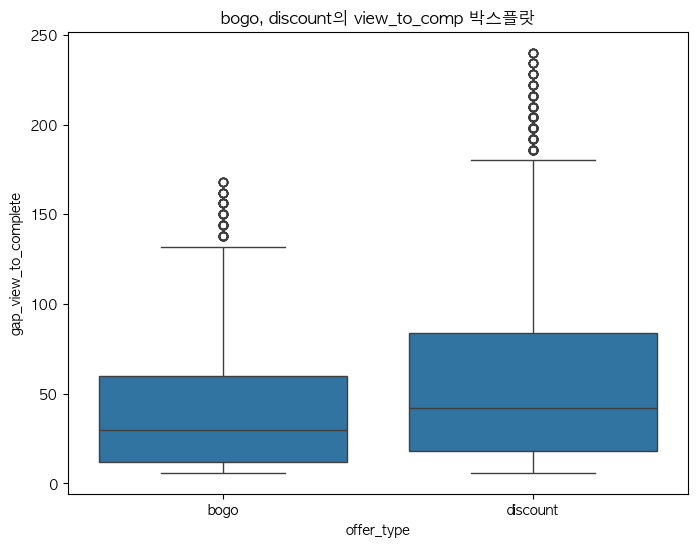

In [183]:
# bogo, discount의 view_to_comp 박스플랏 확인 후 통계검정
temp_df = df[(df['is_completed']==1) & (df['is_viewed']==1)]

import seaborn as sns
plt.figure(figsize=(8, 6))
sns.boxplot(data=temp_df, x='offer_type', y='gap_view_to_complete')
plt.title('bogo, discount의 view_to_comp 박스플랏')
plt.show() 

In [188]:
# bogo, discount의 comp_rate 박스플랏 확인 후 통계검정
temp_df = df.copy()

import seaborn as sns

contingency_table = pd.crosstab(temp_df['offer_type'], temp_df['is_completed'])
print("--- 교차표 (빈도수) ---")
display(contingency_table)

contingency_table = pd.crosstab(temp_df['offer_type'], temp_df['completed_with_prior_view'])
print("--- 교차표 (빈도수) ---")
display(contingency_table)

offer_type_df = df.groupby(['offer_type']).agg( 
    avg_gap_to_view = ('gap_to_view', 'mean'),
    avg_gap_to_comp = ('gap_to_complete', 'mean'), 
    avg_view_to_comp = ('gap_view_to_complete', 'mean'),
    avg_difficulty = ('difficulty', 'mean'),
    avg_duration = ('duration', 'mean'),
    view_rate = ('is_viewed', 'mean'), 
    comp_rate = ('is_completed', 'mean'), 
    aware_rate = ('completed_with_prior_view', 'mean'), 
    unaware_rate = ('completed_without_prior_view', 'mean'), 
    count = ('gender', 'size')
).reset_index()
offer_type_df.sort_values(by=['aware_rate'], ascending=[False]) 

--- 교차표 (빈도수) ---


is_completed,0,1
offer_type,,
bogo,14998,15501
discount,12943,17600
informational,15235,0


--- 교차표 (빈도수) ---


completed_with_prior_view,0,1
offer_type,,
bogo,21086,9413
discount,19408,11135
informational,15235,0


,offer_type,avg_gap_to_view,avg_gap_to_comp,avg_view_to_comp,avg_difficulty,avg_duration,view_rate,comp_rate,aware_rate,unaware_rate,count
1,discount,25.832007,71.402386,58.716480,11.759552,8.499362,0.699669,0.576237,0.364568,0.172675,30543
0,bogo,23.815842,49.562609,41.922873,7.500246,6.005607,0.827896,0.508246,0.308633,0.149513,30499
2,informational,22.610837,NaN,NaN,0.000000,3.499967,0.652904,0.000000,0.000000,0.000000,15235


In [ ]:
# bogo, discount의 aware_rate 박스플랏 확인 후 통계검정

- view_rate을 계산할때는 전체 데이터 사용
- avg_gap_to comp, avg_view_to_comp, aware_rate을 계산할 때는 무조건 completed_without_prior_view==0인 데이터 사용

In [174]:
channel_offertype_df_rate = df[df['completed_without_prior_view']==0].groupby(['offer_type', 'channel_count']).agg( 
    avg_gap_to_view = ('gap_to_view', 'mean'),
    avg_gap_to_comp = ('gap_to_complete', 'mean'), 
    avg_view_to_comp = ('gap_view_to_complete', 'mean'),
    avg_difficulty = ('difficulty', 'mean'),
    avg_duration = ('duration', 'mean'),
    view_rate = ('is_viewed', 'mean'), 
    comp_rate = ('is_completed', 'mean'), 
    aware_rate = ('completed_with_prior_view', 'mean'), 
    count = ('gender', 'size')
).reset_index()
channel_offertype_df_rate.sort_values(by=['avg_view_to_comp'], ascending=[False])

,offer_type,channel_count,avg_gap_to_view,avg_gap_to_comp,avg_view_to_comp,avg_difficulty,avg_duration,view_rate,comp_rate,aware_rate,count
2,discount,2.0,40.636025,100.984615,69.589154,20.000000,10.000000,0.427056,0.229885,0.215208,5655
4,discount,4.0,18.532290,70.024653,59.409861,8.505529,8.505529,0.979328,0.645031,0.580557,13835
3,discount,3.0,28.370412,66.533777,48.747614,10.000000,7.000000,0.612909,0.363731,0.326354,5779
0,bogo,3.0,25.936349,61.396331,46.641593,7.732727,7.000000,0.795614,0.387919,0.336616,12085
1,bogo,4.0,17.710617,46.607708,38.331525,7.537534,5.000000,0.966797,0.451350,0.385809,13854
5,informational,3.0,22.610837,NaN,NaN,0.000000,3.499967,0.652904,0.000000,0.000000,15235


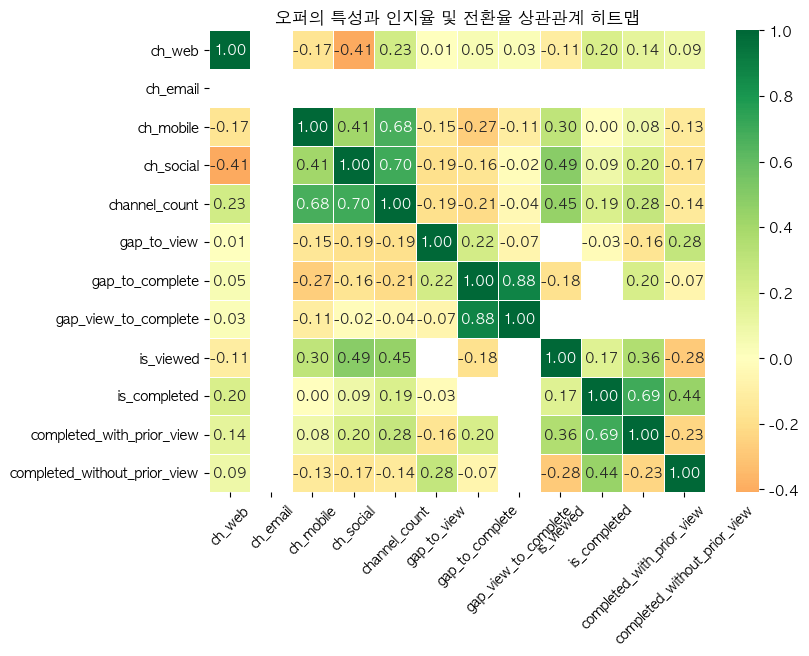

In [138]:
import seaborn as sns

ch_correlation = df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'gap_to_view', 'gap_to_complete', 'gap_view_to_complete',
                  'is_viewed', 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']].corr()
# 히트맵 (전체적인 상관관계 파악)

plt.figure(figsize=(8, 6))
sns.heatmap(ch_correlation, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
plt.title('오퍼의 특성과 인지율 및 전환율 상관관계 히트맵')
plt.xticks(rotation=45)
plt.show() 

In [139]:
discount_df = df[df['offer_type']=='discount']
bogo_df = df[df['offer_type']=='bogo']

discount_corr = discount_df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'gap_to_view', 'gap_to_complete', 'gap_view_to_complete',
                  'is_viewed', 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']].corr()
bogo_corr = bogo_df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'gap_to_view', 'gap_to_complete', 'gap_view_to_complete',
                  'is_viewed', 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']].corr()

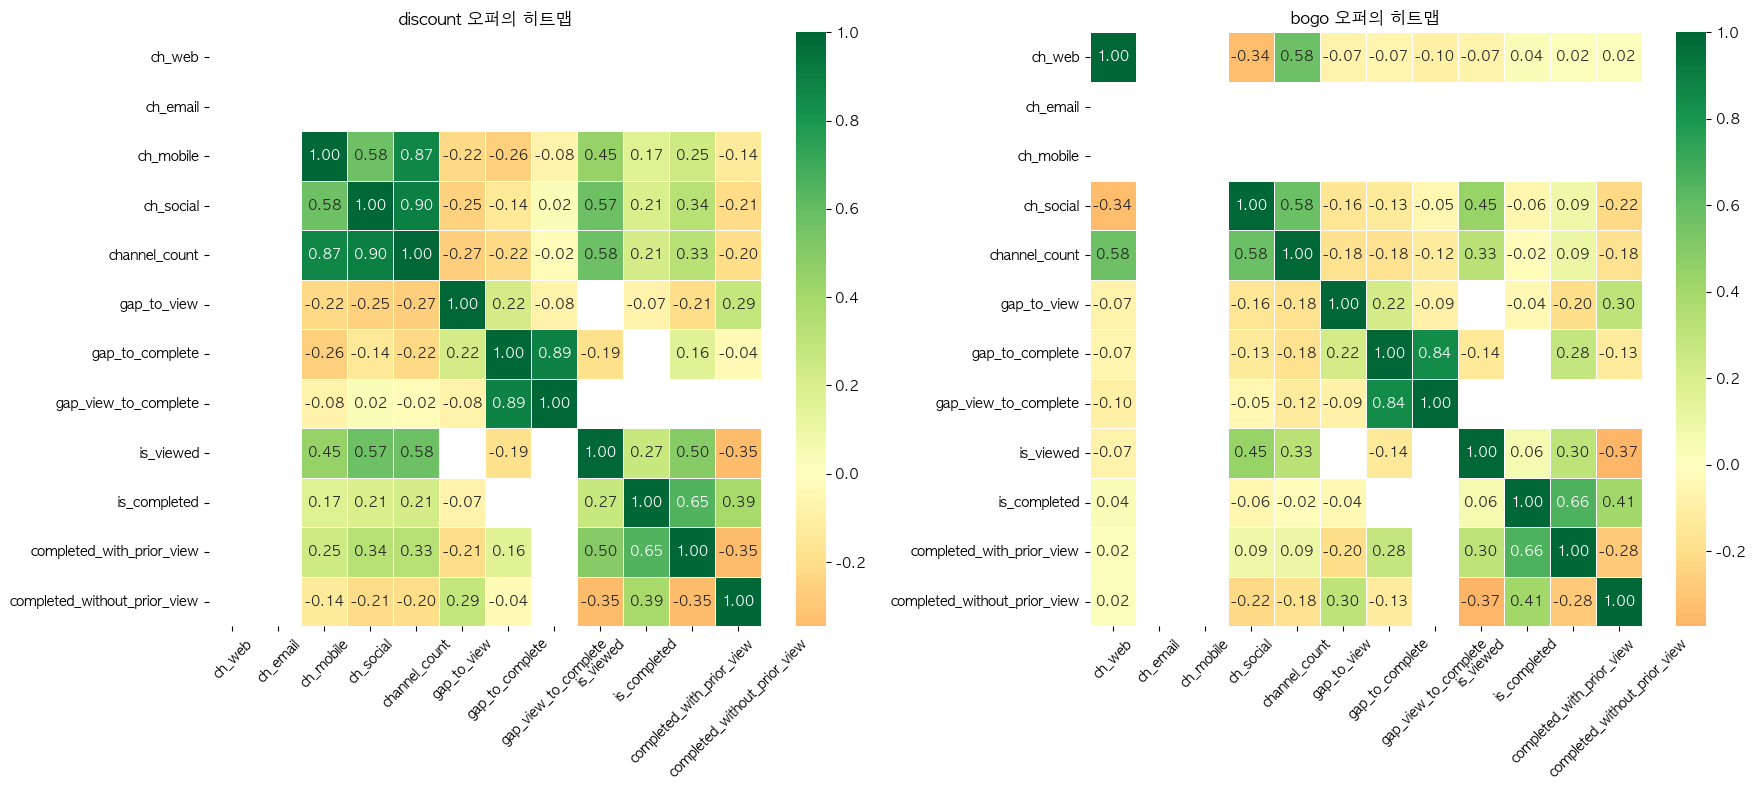

In [140]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax1 = axes[0]
ax2 = axes[1]
label = ['discount', 'bogo']

sns.heatmap(discount_corr, ax=ax1, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
sns.heatmap(bogo_corr, ax=ax2, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)

for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=45)

ax1.set_title(f"{label[0]} 오퍼의 히트맵")
ax2.set_title(f"{label[1]} 오퍼의 히트맵")

plt.tight_layout()
plt.show()

In [141]:
# 소셜 채널의 avg_gap_to_view 영향력에 대한 통계검정

In [142]:
df['view_count'].value_counts()

view_count
1.0    56567
Name: count, dtype: int64

In [143]:
df['complete_count'].value_counts() # 같은 오퍼에 대해서 같은 고객이 몇 번을 complete 했는지 카운트

complete_count
1.0    32624
2.0      476
3.0        1
Name: count, dtype: int64

In [144]:
df[df['complete_count']>1] # groupby

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,t_viewed,last_viewed,view_count,view_ambiguous,t_completed,last_completed,complete_count,comp_ambiguous,gap_to_view,gap_to_complete,is_viewed,is_completed,completed_without_prior_view,gap_view_to_complete,reward,difficulty,ch_web,ch_email,ch_mobile,ch_social,channel_count,gender,age_group,income_group,join_year,join_month,join_cohort,completed_with_prior_view
211,00d7c95f793a4212af44e632fdc1e431,2906b810c7d4411798c6938adc9daaa5,504,discount,2,7.0,672.0,NaN,NaN,NaN,NaN,504.0,504.0,2.0,1.0,NaN,0.0,0,1,1,NaN,2.0,10.0,1.0,1.0,1.0,0.0,3.0,M,60대 이상,7.5-10만,2016,12,2016-12,0
426,01925607d99c460996c281f17cdbb9e2,4d5c57ea9a6940dd891ad53e9dbe8da0,504,bogo,2,5.0,624.0,NaN,NaN,NaN,NaN,510.0,510.0,2.0,1.0,NaN,6.0,0,1,1,NaN,10.0,10.0,1.0,1.0,1.0,1.0,4.0,F,50대,10만 이상,2015,11,2015-11,0
437,01956670cf414b309675aa73368b94a9,2906b810c7d4411798c6938adc9daaa5,408,discount,2,7.0,576.0,NaN,NaN,NaN,NaN,420.0,420.0,2.0,1.0,NaN,12.0,0,1,1,NaN,2.0,10.0,1.0,1.0,1.0,0.0,3.0,M,50대,7.5-10만,2016,8,2016-08,0
537,01ff6c5d8d014dbd8c120e2b43a065ea,9b98b8c7a33c4b65b9aebfe6a799e6d9,408,bogo,2,7.0,576.0,432.0,432.0,1.0,1.0,444.0,444.0,2.0,1.0,24.0,36.0,1,1,0,12.0,5.0,5.0,1.0,1.0,1.0,0.0,3.0,F,50대,5-7.5만,2017,4,2017-04,1
543,0200f61c69da4c2ea078842cdaf234e6,2906b810c7d4411798c6938adc9daaa5,408,discount,2,7.0,576.0,420.0,420.0,1.0,1.0,450.0,450.0,2.0,1.0,12.0,42.0,1,1,0,30.0,2.0,10.0,1.0,1.0,1.0,0.0,3.0,M,60대 이상,7.5-10만,2016,12,2016-12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75895,feb31e39c1e3407b9fdc7e79db9274b7,fafdcd668e3743c1bb461111dcafc2a4,504,discount,2,10.0,744.0,NaN,NaN,NaN,NaN,594.0,594.0,2.0,1.0,NaN,90.0,0,1,1,NaN,2.0,10.0,1.0,1.0,1.0,1.0,4.0,M,40대,5만 미만,2017,5,2017-05,0
76047,ff4bfebc3c92451aa546c7e100be0de4,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,bogo,2,7.0,672.0,NaN,NaN,NaN,NaN,504.0,504.0,2.0,1.0,NaN,0.0,0,1,1,NaN,5.0,5.0,1.0,1.0,1.0,0.0,3.0,M,40대,5만 미만,2016,5,2016-05,0
76078,ff6a080134fc44dc9c7e7b5abcfbe849,ae264e3637204a6fb9bb56bc8210ddfd,576,bogo,3,7.0,744.0,NaN,NaN,NaN,NaN,600.0,600.0,2.0,1.0,NaN,24.0,0,1,1,NaN,10.0,10.0,0.0,1.0,1.0,1.0,3.0,M,60대 이상,10만 이상,2017,12,2017-12,0
76115,ff80a43ecb34439491bd9ae1cff7c5fc,fafdcd668e3743c1bb461111dcafc2a4,408,discount,2,10.0,648.0,444.0,444.0,1.0,1.0,528.0,528.0,2.0,1.0,36.0,120.0,1,1,0,84.0,2.0,10.0,1.0,1.0,1.0,1.0,4.0,M,50대,5-7.5만,2014,2,2014-02,1


- 인지율 : 이벤트 인지를 한 채로 완료한 바람직한 경우 (t_viewed < t_completed)
- 비인지율 : 이벤트 인지를 하지도 않은 채로 우연히 완료한 경우 (마케팅 효과가 있다고 볼 수 없음)

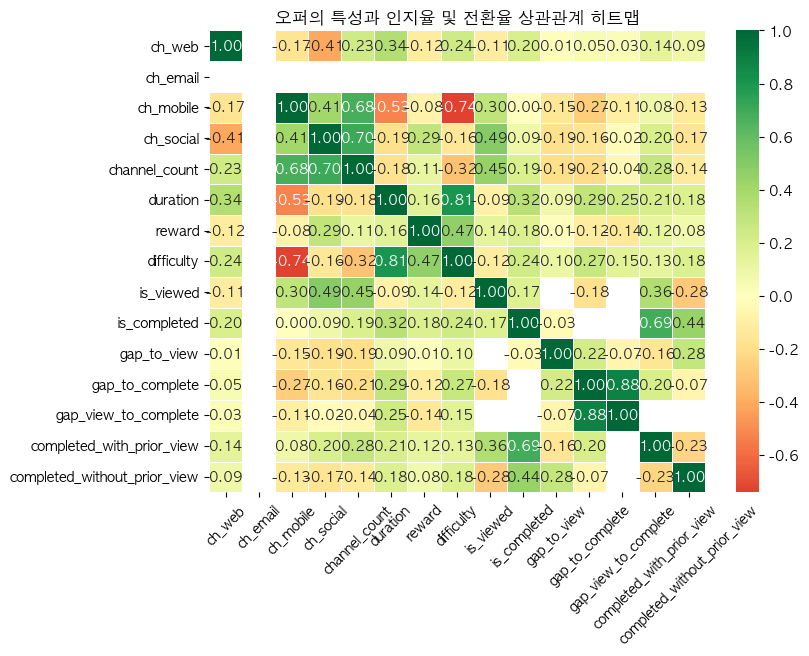

In [184]:
import seaborn as sns

correlation = df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'duration', 'reward', 'difficulty', 'is_viewed', 'is_completed', 
                  'gap_to_view', 'gap_to_complete', 'gap_view_to_complete', 'completed_with_prior_view', 'completed_without_prior_view']].corr()
# 히트맵 (전체적인 상관관계 파악)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
plt.title('오퍼의 특성과 인지율 및 전환율 상관관계 히트맵')
plt.xticks(rotation=45)
plt.show() 

In [146]:
discount_df = df[df['offer_type']=='discount']
bogo_df = df[df['offer_type']=='bogo']

discount_corr = discount_df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'duration', 'reward', 'difficulty', 'is_viewed', 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']].corr()

bogo_corr = bogo_df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'duration', 'reward', 'difficulty', 'is_viewed', 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']].corr()

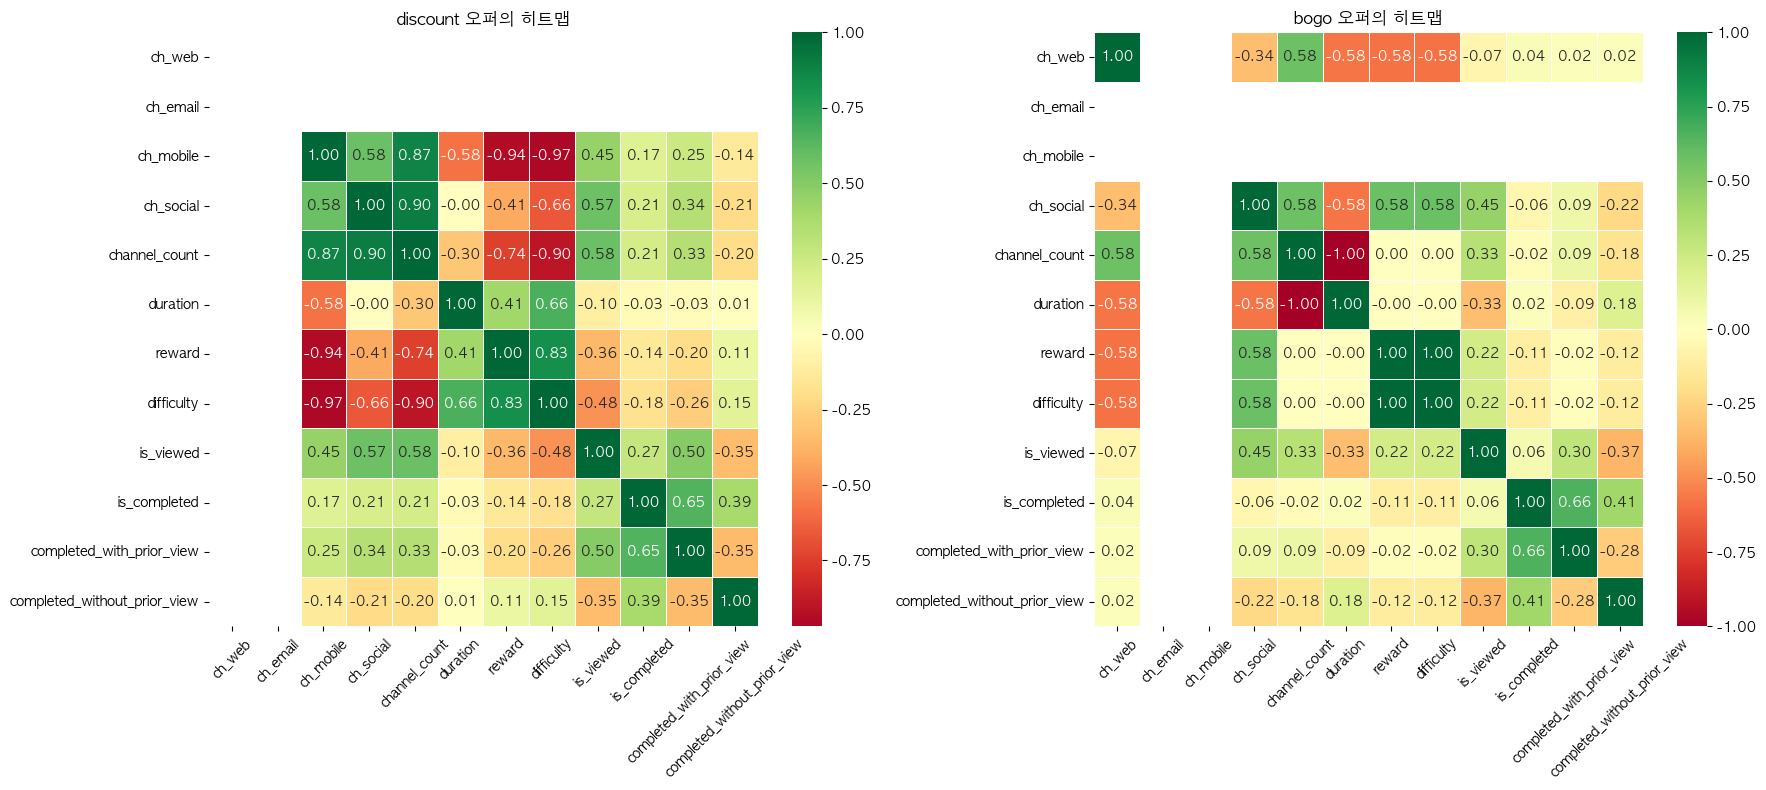

In [147]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax1 = axes[0]
ax2 = axes[1]
label = ['discount', 'bogo']

sns.heatmap(discount_corr, ax=ax1, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
sns.heatmap(bogo_corr, ax=ax2, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)

for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=45)

ax1.set_title(f"{label[0]} 오퍼의 히트맵")
ax2.set_title(f"{label[1]} 오퍼의 히트맵")

plt.tight_layout()
plt.show()

In [148]:
target_cols = ['is_viewed', 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']

offer_df_rate = df.groupby(['offer_id', 'channel_count', 'offer_type', 'duration', 'reward', 'difficulty']).agg(
    view_rate = ('is_viewed', 'mean'), 
    comp_rate = ('is_completed', 'mean'), 
    aware_rate = ('completed_with_prior_view', 'mean'), 
    unaware_rate = ('completed_without_prior_view', 'mean'), 
    count = ('gender', 'size')
).reset_index()
offer_df_rate.sort_values(by=['aware_rate', 'unaware_rate'], ascending=[False,True])

,offer_id,channel_count,offer_type,duration,reward,difficulty,view_rate,comp_rate,aware_rate,unaware_rate,count
9,fafdcd668e3743c1bb461111dcafc2a4,4.0,discount,10.0,2.0,10.0,0.964460,0.688430,0.546005,0.086087,7597
1,2298d6c36e964ae4a3e7e9706d1fb8c2,4.0,discount,7.0,3.0,7.0,0.958671,0.667277,0.507978,0.098614,7646
8,f19421c1d4aa40978ebb69ca19b0e20d,4.0,bogo,5.0,5.0,5.0,0.952054,0.562938,0.394928,0.098798,7571
4,4d5c57ea9a6940dd891ad53e9dbe8da0,4.0,bogo,5.0,10.0,10.0,0.952851,0.434743,0.310154,0.074016,7593
7,ae264e3637204a6fb9bb56bc8210ddfd,3.0,bogo,7.0,10.0,10.0,0.872160,0.474667,0.292766,0.137503,7658
2,2906b810c7d4411798c6938adc9daaa5,3.0,discount,7.0,2.0,10.0,0.532102,0.518213,0.247117,0.242794,7632
6,9b98b8c7a33c4b65b9aebfe6a799e6d9,3.0,bogo,7.0,5.0,5.0,0.537710,0.560505,0.237853,0.286179,7677
0,0b1e1539f2cc45b7b9fa7c272da2e1d7,2.0,discount,10.0,5.0,20.0,0.345853,0.432055,0.158712,0.262520,7668
3,3f207df678b143eea3cee63160fa8bed,3.0,informational,4.0,0.0,0.0,0.498622,0.000000,0.000000,0.000000,7617
5,5a8bc65990b245e5a138643cd4eb9837,3.0,informational,3.0,0.0,0.0,0.807167,0.000000,0.000000,0.000000,7618


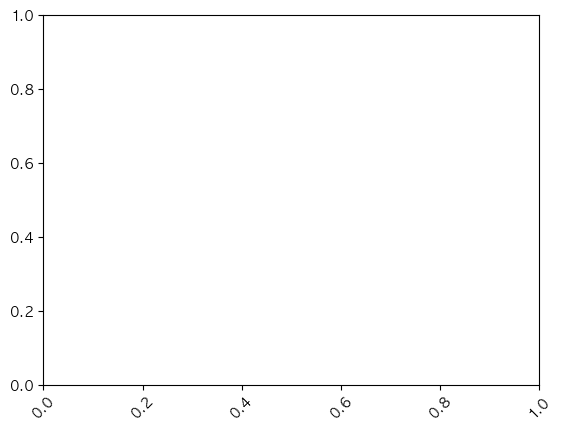

In [149]:
# 채널별 열람률, 완료율, 비인지율(완료는 했는데 이벤트 인지를 못하고 우연히 한 경우), 인지율(이벤트 인지한 채로 완료한 바람직한 경우) 확인
# 비율만 표시하면 공정한 결과가 아니므로, 각 그룹의 데이터 개수도 함께 표시
df[df['ch_web']==1]['is_viewed'].value_counts(normalize=True)

plt.xticks(rotation=45)
plt.show() 

In [150]:
viewed_rate = df.groupby(['offer_id', 'channel_count', 'offer_type', 'duration', 'reward', 'difficulty'])['is_viewed'].mean()
viewed_rate

offer_id                          channel_count  offer_type     duration  reward  difficulty
0b1e1539f2cc45b7b9fa7c272da2e1d7  2.0            discount       10.0      5.0     20.0          0.345853
2298d6c36e964ae4a3e7e9706d1fb8c2  4.0            discount       7.0       3.0     7.0           0.958671
2906b810c7d4411798c6938adc9daaa5  3.0            discount       7.0       2.0     10.0          0.532102
3f207df678b143eea3cee63160fa8bed  3.0            informational  4.0       0.0     0.0           0.498622
4d5c57ea9a6940dd891ad53e9dbe8da0  4.0            bogo           5.0       10.0    10.0          0.952851
5a8bc65990b245e5a138643cd4eb9837  3.0            informational  3.0       0.0     0.0           0.807167
9b98b8c7a33c4b65b9aebfe6a799e6d9  3.0            bogo           7.0       5.0     5.0           0.537710
ae264e3637204a6fb9bb56bc8210ddfd  3.0            bogo           7.0       10.0    10.0          0.872160
f19421c1d4aa40978ebb69ca19b0e20d  4.0            bogo           5.0

In [151]:
completed_rate = df.groupby(['offer_id', 'channel_count', 'offer_type', 'duration', 'reward', 'difficulty'])['is_completed'].mean()
completed_rate

offer_id                          channel_count  offer_type     duration  reward  difficulty
0b1e1539f2cc45b7b9fa7c272da2e1d7  2.0            discount       10.0      5.0     20.0          0.432055
2298d6c36e964ae4a3e7e9706d1fb8c2  4.0            discount       7.0       3.0     7.0           0.667277
2906b810c7d4411798c6938adc9daaa5  3.0            discount       7.0       2.0     10.0          0.518213
3f207df678b143eea3cee63160fa8bed  3.0            informational  4.0       0.0     0.0           0.000000
4d5c57ea9a6940dd891ad53e9dbe8da0  4.0            bogo           5.0       10.0    10.0          0.434743
5a8bc65990b245e5a138643cd4eb9837  3.0            informational  3.0       0.0     0.0           0.000000
9b98b8c7a33c4b65b9aebfe6a799e6d9  3.0            bogo           7.0       5.0     5.0           0.560505
ae264e3637204a6fb9bb56bc8210ddfd  3.0            bogo           7.0       10.0    10.0          0.474667
f19421c1d4aa40978ebb69ca19b0e20d  4.0            bogo           5.0

In [152]:
aware_rate = df.groupby(['offer_id', 'channel_count', 'offer_type', 'duration', 'reward', 'difficulty'])['completed_with_prior_view'].mean()
aware_rate

offer_id                          channel_count  offer_type     duration  reward  difficulty
0b1e1539f2cc45b7b9fa7c272da2e1d7  2.0            discount       10.0      5.0     20.0          0.158712
2298d6c36e964ae4a3e7e9706d1fb8c2  4.0            discount       7.0       3.0     7.0           0.507978
2906b810c7d4411798c6938adc9daaa5  3.0            discount       7.0       2.0     10.0          0.247117
3f207df678b143eea3cee63160fa8bed  3.0            informational  4.0       0.0     0.0           0.000000
4d5c57ea9a6940dd891ad53e9dbe8da0  4.0            bogo           5.0       10.0    10.0          0.310154
5a8bc65990b245e5a138643cd4eb9837  3.0            informational  3.0       0.0     0.0           0.000000
9b98b8c7a33c4b65b9aebfe6a799e6d9  3.0            bogo           7.0       5.0     5.0           0.237853
ae264e3637204a6fb9bb56bc8210ddfd  3.0            bogo           7.0       10.0    10.0          0.292766
f19421c1d4aa40978ebb69ca19b0e20d  4.0            bogo           5.0

In [153]:
unaware_rate = df.groupby(['offer_id', 'channel_count', 'offer_type', 'duration', 'reward', 'difficulty'])['completed_without_prior_view'].mean()
unaware_rate

offer_id                          channel_count  offer_type     duration  reward  difficulty
0b1e1539f2cc45b7b9fa7c272da2e1d7  2.0            discount       10.0      5.0     20.0          0.262520
2298d6c36e964ae4a3e7e9706d1fb8c2  4.0            discount       7.0       3.0     7.0           0.098614
2906b810c7d4411798c6938adc9daaa5  3.0            discount       7.0       2.0     10.0          0.242794
3f207df678b143eea3cee63160fa8bed  3.0            informational  4.0       0.0     0.0           0.000000
4d5c57ea9a6940dd891ad53e9dbe8da0  4.0            bogo           5.0       10.0    10.0          0.074016
5a8bc65990b245e5a138643cd4eb9837  3.0            informational  3.0       0.0     0.0           0.000000
9b98b8c7a33c4b65b9aebfe6a799e6d9  3.0            bogo           7.0       5.0     5.0           0.286179
ae264e3637204a6fb9bb56bc8210ddfd  3.0            bogo           7.0       10.0    10.0          0.137503
f19421c1d4aa40978ebb69ca19b0e20d  4.0            bogo           5.0

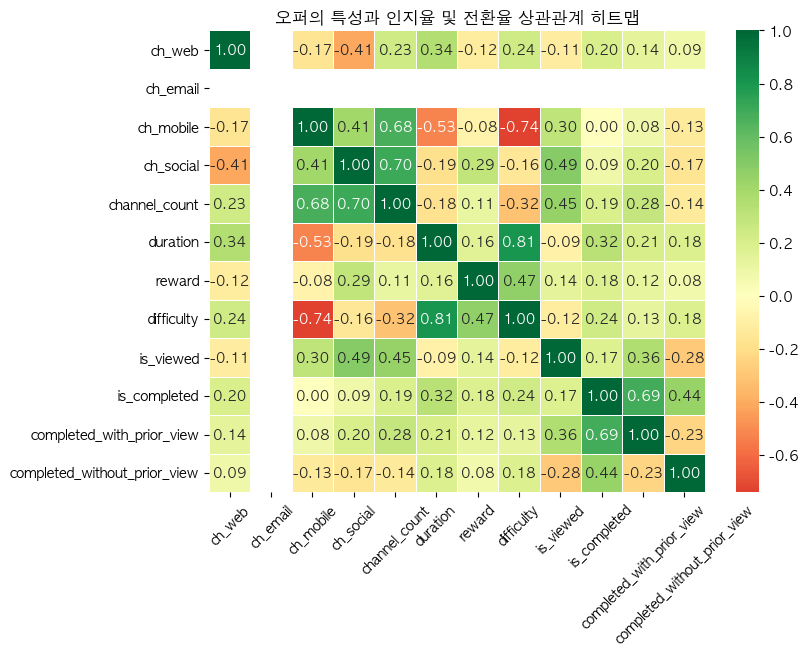

In [154]:
# 채널과 is_viewed, is_completed, completed_without_prior_view, completed_with_prior_view 히트맵 시각화

import seaborn as sns 

correlation = df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'duration', 'reward', 'difficulty', 'is_viewed', 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']].corr()
# 히트맵 (전체적인 상관관계 파악)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
plt.title('오퍼의 특성과 인지율 및 전환율 상관관계 히트맵')
plt.xticks(rotation=45)
plt.show()

In [155]:
# 채널 개수(channel_count)에 따른 열람률, 완료율, 인지율 변화 시각화